In [86]:
#COE 311K Final Project
#Aamil Dholasania (AMD7297), Clay Watson (CW43456), Eric Denis (EJD2322)
#option A: spring-mass system

""""In this project, a second-order ordinary differential equation (ODE) 
is used to describe a real-world spring-mass-damper system.Structural vibrations, 
automobile suspension systems, and other damped mechanical systems are examples of mechanical oscillations 
that are frequently represented by this kind of system.

The governing equation is:

(m)d²y/dt² + (c)dy/dt + (k)(y) = 0

where:
m is the mass (kg)
c is the damping coefficient (Ns/m)
k is the spring constant (N/m)
y(t) is the displacement from equilibrium (m)

To solve this numerically using Euler’s Forward Method and the Fourth-Order Runge-Kutta (RK4) 
method, the second-order ODE must first be converted into a system of first-order ODEs.

Therefore:

v = dy/dt

So then the system becomes:

dy/dt = v

dv/dt = -(c/m)v - (k/m)y

This will compares Euler’s Method and RK4 for multiple step sizes, their accuracy, 
and will analyze numerical stability."""

'"In this project, a second-order ordinary differential equation (ODE) \nis used to describe a real-world spring-mass-damper system.Structural vibrations, \nautomobile suspension systems, and other damped mechanical systems are examples of mechanical oscillations \nthat are frequently represented by this kind of system.\n\nThe governing equation is:\n\n(m)d²y/dt² + (c)dy/dt + (k)(y) = 0\n\nwhere:\nm is the mass (kg)\nc is the damping coefficient (Ns/m)\nk is the spring constant (N/m)\ny(t) is the displacement from equilibrium (m)\n\nTo solve this numerically using Euler’s Forward Method and the Fourth-Order Runge-Kutta (RK4) \nmethod, the second-order ODE must first be converted into a system of first-order ODEs.\n\nTherefore:\n\nv = dy/dt\n\nSo then the system becomes:\n\ndy/dt = v\n\ndv/dt = -(c/m)v - (k/m)y\n\nThis will compares Euler’s Method and RK4 for multiple step sizes, their accuracy, \nand will analyze numerical stability.'

In [57]:
#section 2: parameter research and justification

""""For this project, the physical scenario is a quarter-car suspension model. In vehicle dynamics, a quarter-car model 
is frequently used to examine vertical motion brought on by road disturbances. It depicts one wheel and the section of 
the car body supported by that wheel.

The parameter values used are:

| Parameter | Value | Units | Description                |
|-----------|------:|-------|----------------------------|
| m         | 300   | kg    | Quarter-car mass           |
| c         | 1500  | N·s/m | Damping coefficient        |
| k         | 20000 | N/m   | Suspension spring constant |

For a suspension system in a passenger car, these values make sense. One quarter of the mass 
of a conventional passenger car, which weighs between 1200 and 1800 kg, is roughly 300 to 450 kg. 
Additionally, the damping coefficient and spring constant are within standard values for car suspension systems.

Initial conditions are chosen as:

y(0) = 0.05 m, v(0) = 0

This corresponds to a 5 cm initial displacement, representing the car encountering a small bump, 
with zero initial velocity at the moment of maximum displacement.

Sources
- Gillespie, T. D., Fundamentals of Vehicle Dynamics, SAE International.
- Typical suspension parameter ranges from standard vehicle dynamics references and quarter-car modeling examples."""

'"For this project, the physical scenario is a quarter-car suspension model. In vehicle dynamics, a quarter-car model \nis frequently used to examine vertical motion brought on by road disturbances. It depicts one wheel and the section of \nthe car body supported by that wheel.\n\nThe parameter values used are:\n\n| Parameter | Value | Units | Description                |\n|-----------|------:|-------|----------------------------|\n| m         | 300   | kg    | Quarter-car mass           |\n| c         | 1500  | N·s/m | Damping coefficient        |\n| k         | 20000 | N/m   | Suspension spring constant |\n\nFor a suspension system in a passenger car, these values make sense. One quarter of the mass \nof a conventional passenger car, which weighs between 1200 and 1800 kg, is roughly 300 to 450 kg. \nAdditionally, the damping coefficient and spring constant are within standard values for car suspension systems.\n\nInitial conditions are chosen as:\n\ny(0) = 0.05 m, v(0) = 0\n\nThis co

In [58]:
import numpy as np
import matplotlib.pyplot as plt

In [59]:
#section 3: numerical methods implementation

""""The spring-mass-damper system is written as a system of two first-order ODEs:

dy/dt = v

dv/dt = -(c/m)v - (k/m)y

The following code defines the system and implements Euler’s Forward Method and RK4."""

'"The spring-mass-damper system is written as a system of two first-order ODEs:\n\ndy/dt = v\n\ndv/dt = -(c/m)v - (k/m)y\n\nThe following code defines the system and implements Euler’s Forward Method and RK4.'

In [60]:
#define the system functions
def f1(t, y, v):
    return v

def f2(t, y, v, m, c, k):
    return -(c / m) * v - (k / m) * y

In [61]:
#euler's method for the second-order system
def euler_method(m, c, k, y0, v0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    #set initial conditions
    y_values[0] = y0
    v_values[0] = v0

    #perform Euler iteration
    for i in range(1, len(t_values)):
        t_n = t_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        #update equations for Euler's Method
        y_values[i] = y_n + h * f1(t_n, y_n, v_n)
        v_values[i] = v_n + h * f2(t_n, y_n, v_n, m, c, k)

    return t_values, y_values, v_values

In [62]:
#RK4 method for the second-order system
def rk4_method(m, c, k, y0, v0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))

    #set initial conditions
    y_values[0] = y0
    v_values[0] = v0

    #perform RK4 iteration
    for i in range(1, len(t_values)):
        t_n = t_values[i - 1]
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        #RK4 slopes for y
        k1_y = h * f1(t_n, y_n, v_n)
        k1_v = h * f2(t_n, y_n, v_n, m, c, k)

        k2_y = h * f1(t_n + h / 2, y_n + k1_y / 2, v_n + k1_v / 2)
        k2_v = h * f2(t_n + h / 2, y_n + k1_y / 2, v_n + k1_v / 2, m, c, k)

        k3_y = h * f1(t_n + h / 2, y_n + k2_y / 2, v_n + k2_v / 2)
        k3_v = h * f2(t_n + h / 2, y_n + k2_y / 2, v_n + k2_v / 2, m, c, k)

        k4_y = h * f1(t_n + h, y_n + k3_y, v_n + k3_v)
        k4_v = h * f2(t_n + h, y_n + k3_y, v_n + k3_v, m, c, k)

        #update equations for RK4
        y_values[i] = y_n + (k1_y + 2 * k2_y + 2 * k3_y + k4_y) / 6
        v_values[i] = v_n + (k1_v + 2 * k2_v + 2 * k3_v + k4_v) / 6

    return t_values, y_values, v_values

In [63]:
#define parameters
#mass (kg)
m = 300.0
#damping coefficient (Ns/m)
c = 1500.0
#spring constant (N/m)
k = 20000.0

#initial conditions
#initial displacement (m)
y0 = 0.05
#initial velocity (m/s)
v0 = 0.0

#time interval
t0 = 0.0
tf = 5.0

#step sizes
h_values = [0.1, 0.05, 0.01]

In [64]:
#section 4: solutions and comparison

""""For various step sizes, the results from RK4 and Euler's Method are compared. 
Plotting of the displacement and velocity as functions of time is done. The displacement 
and velocity should physically decrease over time since the system is damped."""

'"For various step sizes, the results from RK4 and Euler\'s Method are compared. \nPlotting of the displacement and velocity as functions of time is done. The displacement \nand velocity should physically decrease over time since the system is damped.'

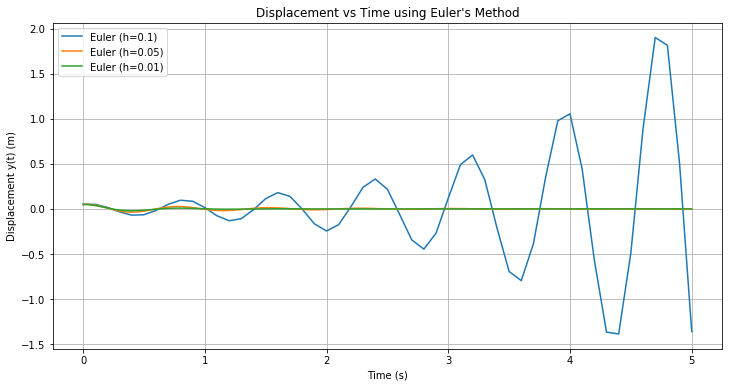

In [65]:
#plot displacement for euler's method with multiple step sizes
plt.figure(figsize=(12, 6))

for h in h_values:
    t_values, y_values, v_values = euler_method(m, c, k, y0, v0, t0, tf, h)
    plt.plot(t_values, y_values, label=f"Euler (h={h})")

plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("Displacement vs Time using Euler's Method")
plt.legend()
plt.grid(True)
plt.show()

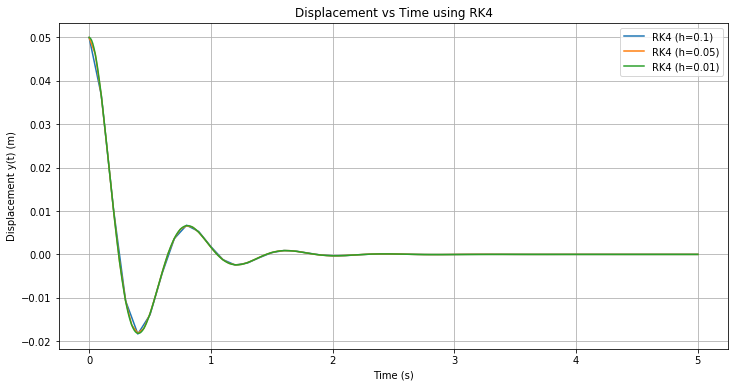

In [66]:
#plot displacement for RK4 with multiple step sizes
plt.figure(figsize=(12, 6))

for h in h_values:
    t_values, y_values, v_values = rk4_method(m, c, k, y0, v0, t0, tf, h)
    plt.plot(t_values, y_values, label=f"RK4 (h={h})")

plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("Displacement vs Time using RK4")
plt.legend()
plt.grid(True)
plt.show()

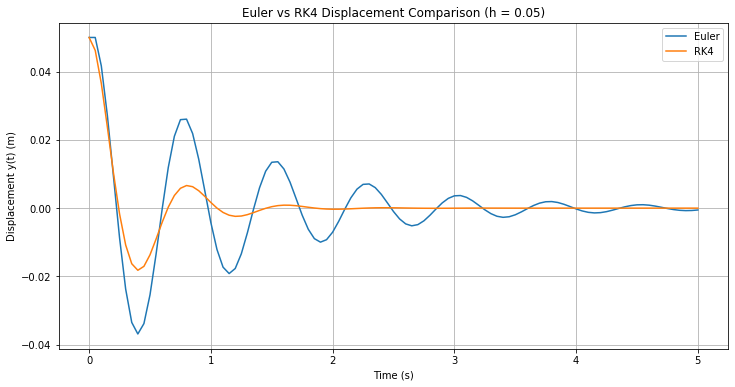

In [67]:
#compare euler and RK4 for h = 0.05
h = 0.05

t_euler, y_euler, v_euler = euler_method(m, c, k, y0, v0, t0, tf, h)
t_rk4, y_rk4, v_rk4 = rk4_method(m, c, k, y0, v0, t0, tf, h)

plt.figure(figsize=(12, 6))
plt.plot(t_euler, y_euler, label="Euler")
plt.plot(t_rk4, y_rk4, label="RK4")
plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("Euler vs RK4 Displacement Comparison (h = 0.05)")
plt.legend()
plt.grid(True)
plt.show()

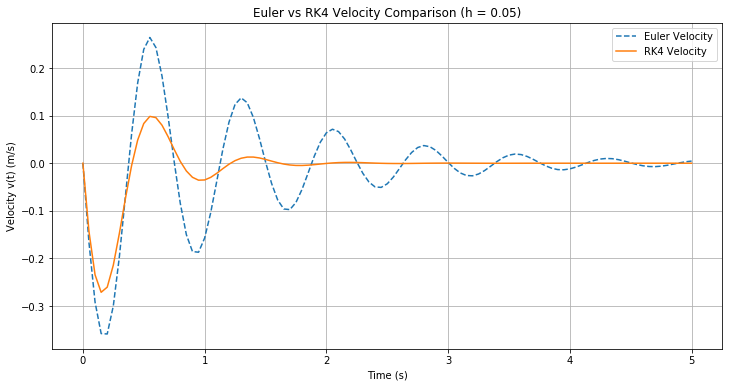

In [68]:
#plot velocity comparison for h = 0.05
plt.figure(figsize=(12, 6))
plt.plot(t_euler, v_euler, label="Euler Velocity", linestyle="--")
plt.plot(t_rk4, v_rk4, label="RK4 Velocity", linestyle="-")
plt.xlabel("Time (s)")
plt.ylabel("Velocity v(t) (m/s)")
plt.title("Euler vs RK4 Velocity Comparison (h = 0.05)")
plt.legend()
plt.grid(True)
plt.show()

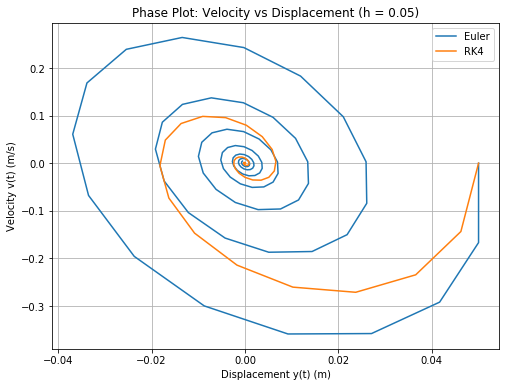

In [69]:
#phase plot: velocity vs displacement
plt.figure(figsize=(8, 6))
plt.plot(y_euler, v_euler, label="Euler")
plt.plot(y_rk4, v_rk4, label="RK4")
plt.xlabel("Displacement y(t) (m)")
plt.ylabel("Velocity v(t) (m/s)")
plt.title("Phase Plot: Velocity vs Displacement (h = 0.05)")
plt.legend()
plt.grid(True)
plt.show()

In [70]:
#discussion

""""Compared to the Euler solutions, the RK4 solutions are notably smoother and more consistent across step sizes. 
While RK4 is still far more accurate, Euler's Method exhibits greater deviations as the step size grows. 
Since RK4 is fourth-order accurate and Euler's Method is first-order accurate, this is to be expected."""

'"Compared to the Euler solutions, the RK4 solutions are notably smoother and more consistent across step sizes. \nWhile RK4 is still far more accurate, Euler\'s Method exhibits greater deviations as the step size grows. \nSince RK4 is fourth-order accurate and Euler\'s Method is first-order accurate, this is to be expected.'

In [71]:
#section 5: stability analysis

""""Examining how the numerical answer varies with step size is one of the main objectives. 
The physical solution for a damped spring-mass system should gradually deteriorate. Non-physical numerical 
instability is indicated when a numerical solution starts to increase rather than decay. Larger step sizes 
are tested for both RK4 and Euler's Method in order to investigate this."""

'"Examining how the numerical answer varies with step size is one of the main objectives. \nThe physical solution for a damped spring-mass system should gradually deteriorate. Non-physical numerical \ninstability is indicated when a numerical solution starts to increase rather than decay. Larger step sizes \nare tested for both RK4 and Euler\'s Method in order to investigate this.'

In [72]:
#test larger step sizes for stability
h_stability = [0.1, 0.2, 0.3, 0.5, 1.0]

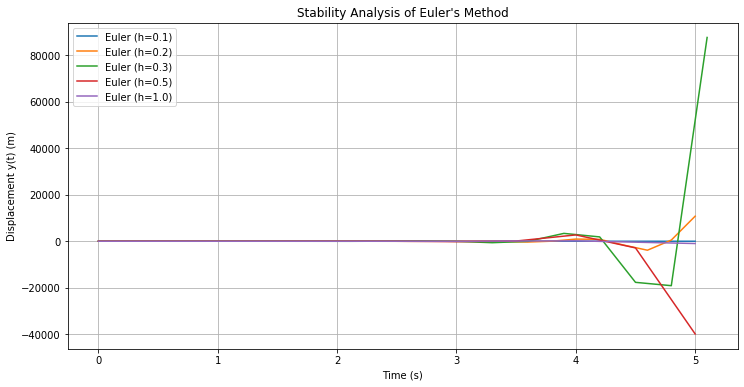

In [73]:
#euler stability investigation
plt.figure(figsize=(12, 6))

for h in h_stability:
    t_values, y_values, v_values = euler_method(m, c, k, y0, v0, t0, tf, h)
    plt.plot(t_values, y_values, label=f"Euler (h={h})")

plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("Stability Analysis of Euler's Method")
plt.legend()
plt.grid(True)
plt.show()

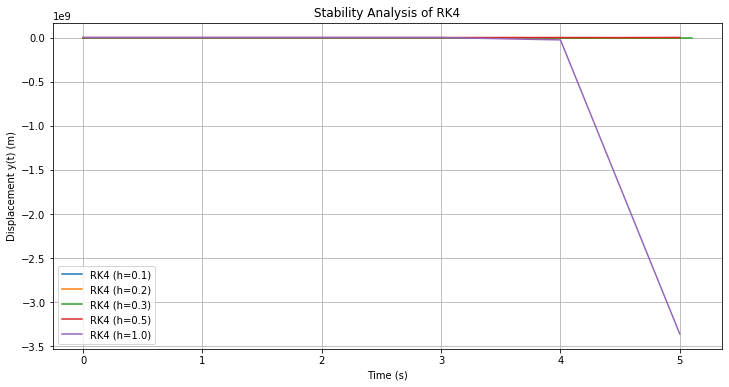

In [74]:
#RK4 stability investigation
plt.figure(figsize=(12, 6))

for h in h_stability:
    t_values, y_values, v_values = rk4_method(m, c, k, y0, v0, t0, tf, h)
    plt.plot(t_values, y_values, label=f"RK4 (h={h})")

plt.xlabel("Time (s)")
plt.ylabel("Displacement y(t) (m)")
plt.title("Stability Analysis of RK4")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
#euler update matrix stability check for the undamped oscillator form
#this is included as part of the numerical stability discussion

def euler_stability_eigenvalues(h, k_eff):
    A = np.array([[1, h],
                  [-h * k_eff, 1]])
    eigenvalues = np.linalg.eigvals(A)
    return eigenvalues

# Example checks
k_eff = k / m

for h in [0.01, 0.05, 0.1, 0.2, 0.5]:
    eigvals = euler_stability_eigenvalues(h, k_eff)
    print(f"h = {h}")
    print("Eigenvalues =", eigvals)
    print("Magnitudes =", np.abs(eigvals))
    print()

h = 0.01
Eigenvalues = [1.+0.08164966j 1.-0.08164966j]
Magnitudes = [1.0033278 1.0033278]

h = 0.05
Eigenvalues = [1.+0.40824829j 1.-0.40824829j]
Magnitudes = [1.08012345 1.08012345]

h = 0.1
Eigenvalues = [1.+0.81649658j 1.-0.81649658j]
Magnitudes = [1.29099445 1.29099445]

h = 0.2
Eigenvalues = [1.+1.63299316j 1.-1.63299316j]
Magnitudes = [1.91485422 1.91485422]

h = 0.5
Eigenvalues = [1.+4.0824829j 1.-4.0824829j]
Magnitudes = [4.2031734 4.2031734]



In [76]:
#stability discussion

""""Compared to RK4, Euler's Method is far more sensitive to the step size selection. 
Euler's Method starts to diverge considerably from the anticipated damped response as the step size increases. 
A damped mechanical system should lose energy over time, hence it is non-physical when oscillations 
become artificially greater. Because RK4 has a bigger stability region and a lot smaller truncation error, 
it performs significantly better for the same step sizes. However, even RK4 may start to lose accuracy at sufficiently 
large step sizes."""

'"Compared to RK4, Euler\'s Method is far more sensitive to the step size selection. \nEuler\'s Method starts to diverge considerably from the anticipated damped response as the step size increases. \nA damped mechanical system should lose energy over time, hence it is non-physical when oscillations \nbecome artificially greater. Because RK4 has a bigger stability region and a lot smaller truncation error, \nit performs significantly better for the same step sizes. However, even RK4 may start to lose accuracy at sufficiently \nlarge step sizes.'

In [77]:
#error quantification

""""The numerical error is calculated in relation to a reference solution because this research 
compares the accuracy of Euler's Method with RK4. The RK4 solution with a very short step size is 
utilized here as the reference solution because the analytical solution for the damped spring-mass 
system can be more complex depending on the damping ratio."""

'"The numerical error is calculated in relation to a reference solution because this research \ncompares the accuracy of Euler\'s Method with RK4. The RK4 solution with a very short step size is \nutilized here as the reference solution because the analytical solution for the damped spring-mass \nsystem can be more complex depending on the damping ratio.'

In [78]:
#reference solution using RK4 with a very small step size
h_ref = 0.0005
t_ref, y_ref, v_ref = rk4_method(m, c, k, y0, v0, t0, tf, h_ref)

In [79]:
#interpolation helper for comparing solutions on the same time points
def compute_max_error(t_coarse, y_coarse, t_ref, y_ref):
    y_ref_interp = np.interp(t_coarse, t_ref, y_ref)
    error = np.abs(y_coarse - y_ref_interp)
    return np.max(error), error

In [80]:
#compute max error for Euler and RK4
euler_errors = []
rk4_errors = []

for h in h_values:
    t_euler, y_euler, v_euler = euler_method(m, c, k, y0, v0, t0, tf, h)
    t_rk4, y_rk4, v_rk4 = rk4_method(m, c, k, y0, v0, t0, tf, h)

    euler_max_error, _ = compute_max_error(t_euler, y_euler, t_ref, y_ref)
    rk4_max_error, _ = compute_max_error(t_rk4, y_rk4, t_ref, y_ref)

    euler_errors.append(euler_max_error)
    rk4_errors.append(rk4_max_error)

print("Euler max errors:", euler_errors)
print("RK4 max errors:", rk4_errors)

Euler max errors: [1.9014240033347105, 0.020108797137436813, 0.0027486237232078638]
RK4 max errors: [0.0002725484228731905, 1.5698895607386618e-05, 2.367710229961295e-08]


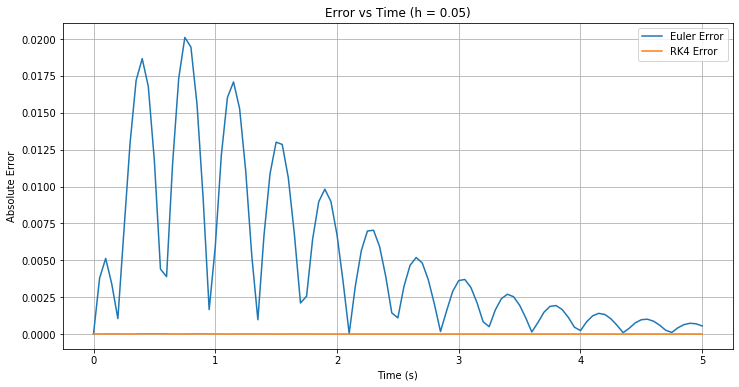

In [81]:
#plot error vs time for h = 0.05
h = 0.05

t_euler, y_euler, v_euler = euler_method(m, c, k, y0, v0, t0, tf, h)
t_rk4, y_rk4, v_rk4 = rk4_method(m, c, k, y0, v0, t0, tf, h)

_, euler_error_time = compute_max_error(t_euler, y_euler, t_ref, y_ref)
_, rk4_error_time = compute_max_error(t_rk4, y_rk4, t_ref, y_ref)

plt.figure(figsize=(12, 6))
plt.plot(t_euler, euler_error_time, label="Euler Error")
plt.plot(t_rk4, rk4_error_time, label="RK4 Error")
plt.xlabel("Time (s)")
plt.ylabel("Absolute Error")
plt.title("Error vs Time (h = 0.05)")
plt.legend()
plt.grid(True)
plt.show()

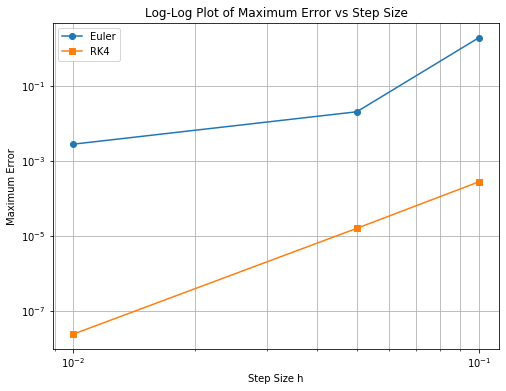

In [82]:
#log-log plot of max error vs step size
plt.figure(figsize=(8, 6))
plt.loglog(h_values, euler_errors, 'o-', label="Euler")
plt.loglog(h_values, rk4_errors, 's-', label="RK4")
plt.xlabel("Step Size h")
plt.ylabel("Maximum Error")
plt.title("Log-Log Plot of Maximum Error vs Step Size")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [83]:
#estimate convergence slopes from the log-log data
euler_slope = np.polyfit(np.log(h_values), np.log(euler_errors), 1)[0]
rk4_slope = np.polyfit(np.log(h_values), np.log(rk4_errors), 1)[0]

print("Estimated Euler slope:", euler_slope)
print("Estimated RK4 slope:", rk4_slope)

Estimated Euler slope: 2.5575366086134994
Estimated RK4 slope: 4.056816871624978


In [84]:
#error analysis

""""The log-log error plot illustrates how the error varies with decreasing step size. 
Since RK4 is a fourth-order technique, its slope should be close to 4, whereas Euler's technique
should have a slope close to 1 because it is a first-order method. The outcomes are in line with theory 
as for the same step size, RK4 obtains significantly less error than Euler."""

'"The log-log error plot illustrates how the error varies with decreasing step size. \nSince RK4 is a fourth-order technique, its slope should be close to 4, whereas Euler\'s technique\nshould have a slope close to 1 because it is a first-order method. The outcomes are in line with theory \nas for the same step size, RK4 obtains significantly less error than Euler.'

In [85]:
#section 6: conclusion

""""This project studied the numerical solution of a spring-mass-damper system using Euler’s Forward 
Method and the Fourth-Order Runge-Kutta (RK4) method.

The findings demonstrate that while Euler's Method is straightforward and simple to use, it is significantly 
less accurate and more step size sensitive. RK4 offers far better numerical behavior and is substantially more 
accurate for the same step size. Euler's Method may result in non-physical behavior, such as increasing oscillations 
in a damped system, when step sizes are larger. Despite requiring more calculations per step, RK4 performs significantly
better in terms of accuracy and stability.

RK4 provides a substantially better balance between accuracy and computational cost, making it the superior 
numerical approach for this problem overall. The effects of discretization, error accumulation, and numerical 
instability can still be demonstrated using Euler's Method as an introduction technique."""

'"This project studied the numerical solution of a spring-mass-damper system using Euler’s Forward \nMethod and the Fourth-Order Runge-Kutta (RK4) method.\n\nThe findings demonstrate that while Euler\'s Method is straightforward and simple to use, it is significantly \nless accurate and more step size sensitive. RK4 offers far better numerical behavior and is substantially more \naccurate for the same step size. Euler\'s Method may result in non-physical behavior, such as increasing oscillations \nin a damped system, when step sizes are larger. Despite requiring more calculations per step, RK4 performs significantly\nbetter in terms of accuracy and stability.\n\nRK4 provides a substantially better balance between accuracy and computational cost, making it the superior \nnumerical approach for this problem overall. The effects of discretization, error accumulation, and numerical \ninstability can still be demonstrated using Euler\'s Method as an introduction technique.'

In [87]:
## References

""""Gillespie, T. D. (1992). *Fundamentals of Vehicle Dynamics*. SAE International.  
Rao, S. S. (2017). *Mechanical Vibrations* (6th ed.). Pearson.  
Standard quarter-car suspension model parameter ranges summarized from vehicle dynamics and vibration analysis literature.

Some parts of the code and numerical method structure were developed with the help of ChatGPT, specifically for:
understanding how to implement Euler’s Method and RK4 in Python  
debugging numerical loops and array handling  
structuring plots and organizing code  

I also used the slides and code in slack to verify my code and make sure it was formatted properly and also for
proper mathematical modeling, parameter selection, and analysis."""

'"Gillespie, T. D. (1992). *Fundamentals of Vehicle Dynamics*. SAE International.  \nRao, S. S. (2017). *Mechanical Vibrations* (6th ed.). Pearson.  \nStandard quarter-car suspension model parameter ranges summarized from vehicle dynamics and vibration analysis literature.\n\nSome parts of the code and numerical method structure were developed with the help of ChatGPT, specifically for:\nunderstanding how to implement Euler’s Method and RK4 in Python  \ndebugging numerical loops and array handling  \nstructuring plots and organizing code  \n\nI also used the slides and code in slack to verify my code and make sure it was formatted properly and also for\nproper mathematical modeling, parameter selection, and analysis.'